# Scenario Dashboard
Focuses on visualization (aligned plots + 3D room plots + interactive audio players) for a single training example.

In [15]:
import os
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output, Audio
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Setup project root
PROJECT_ROOT = Path(os.getcwd()).parent
os.environ["PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from hydra import initialize, compose
from hydra.utils import instantiate

# --- CONFIGURATION VARIABLES ---
DATASET = "J3_sanity_check" # "pra_anf_circ_8ch"
# DATASET = "pra_anf_circ_8ch"
EXPERIMENT = "sanity_check"
SPLIT = "train"

with initialize(version_base="1.3", config_path="../configs"):
    # cfg = compose(config_name="default", overrides=[f"dataset={DATASET}"])
    cfg = compose(config_name="default", overrides=[f"experiment={EXPERIMENT}"])

datamodule = instantiate(cfg.dataset)
base_root = datamodule.precomputed_dir
feature_extractor = datamodule.feature_extractor
if hasattr(feature_extractor, 'precompute_type'):
    if feature_extractor.precompute_type == 'features' and not datamodule.force_load_stft:
        data_root = base_root / 'features' / feature_extractor.signature
    elif (feature_extractor.precompute_type == 'stft' or datamodule.force_load_stft) and hasattr(feature_extractor, 'transform') and hasattr(feature_extractor.transform, 'signature'):
        stft_dir = base_root / 'stft' / feature_extractor.transform.signature
        data_root = stft_dir if stft_dir.exists() else base_root
    else:
        data_root = base_root
else:
    data_root = base_root

split_dir = data_root / SPLIT
base_dir = base_root / SPLIT
if not split_dir.exists():
    raise FileNotFoundError(f"Split '{SPLIT}' does not exist at {split_dir}.")

from muse_toolbox.data.components.precomputed_dataset import PrecomputedDataset
dataset = PrecomputedDataset(precomputed_dir=[split_dir], preload_to_ram=False)
dataset_raw = PrecomputedDataset(precomputed_dir=[base_dir], preload_to_ram=False)
print(f"Loaded dataset with {len(dataset)} scenarios.")


Loaded dataset with 4 scenarios.


In [16]:
from hydra._internal import deprecation_warning
def preprocess_item(item, item_raw):
    meta = item['meta']
    raw_audio = item_raw.get('raw_audio', None)
    if isinstance(raw_audio, torch.Tensor): raw_audio = raw_audio[0,:].float().cpu().numpy()
    params = meta.get('scenario_params', {})
    references = meta.get('references', {})
    sad_samples = meta.get('sad_samples', {})
    
    fs = 8000
    hop = 256
    if 'transform' in params:
        t = params['transform']
        if hasattr(t, 'sampling_frequency'): fs = t.sampling_frequency
        if hasattr(t, 'hop_length'): hop = t.hop_length
        elif hasattr(t, 'hop_size'): hop = t.hop_size
            
    speaker_start_times = []
    for k in references.keys():
        if k == 'noise' or k == 'noisy': continue
        start_idx = float('inf')
        if k in sad_samples:
            v = sad_samples[k]
            if isinstance(v, torch.Tensor): v = v.cpu().numpy()
            active = np.where(v > 0.5)[0]
            if len(active) > 0: start_idx = active[0]
        speaker_start_times.append((k, start_idx))
    speaker_start_times.sort(key=lambda x: x[1])
    sorted_speakers = [x[0] for x in speaker_start_times]
    
    ordered_labels = ['noisy']
    if 'noise' in references: ordered_labels.append('noise')
    ordered_labels.extend(sorted_speakers)
    
    signals = {}
    vads = {}
    
    # Extract mono channel (channel 0) for each signal
    for k, sig in references.items():
        if sig.ndim > 1:
            sig = sig[0]  # Mono
        signals[k] = sig.float().cpu().numpy()
        
        v = None
        if k in sad_samples:
            v = sad_samples[k]
            if isinstance(v, torch.Tensor): v = v.float().cpu().numpy()
        vads[k] = v
        
    # If noisy not in references, sum components
    if 'noisy' not in signals:
        if len(references) > 0:
            mix = sum(signals[k] for k in signals)
            signals['noisy'] = mix
            vads['noisy'] = None
        elif raw_audio is not None:
            signals['noisy'] = raw_audio
            vads['noisy'] = None

    num_samples = len(signals['noisy'])
    time_wave = np.arange(num_samples) / fs
    
    features = item.get('features', None)
    feat_time = None
    if features is not None:
        num_frames = features.shape[1]
        feat_time = np.arange(num_frames) * hop / fs
        
    return {
        'fs': fs, 'hop': hop,
        'signals': signals, 'vads': vads,
        'labels': ordered_labels,
        'time_wave': time_wave,
        'features': features,
        'time_feat': feat_time,
        'prediction': None, # Adjust if prediction available
        'params': params,
        'refs': references,
        'gt_count_samples': torch.stack([v for k, v in sad_samples.items() if k != 'noise']).sum(dim =0),
        'gt_count_frames': torch.stack([v for k, v in meta.get('sad_frames').items() if k != 'noise']).sum(dim =0), # Adjust if frame-level count available
        
    }
    
item = dataset[0]
item_raw = dataset_raw[0]
proc_data = preprocess_item(item, item_raw)


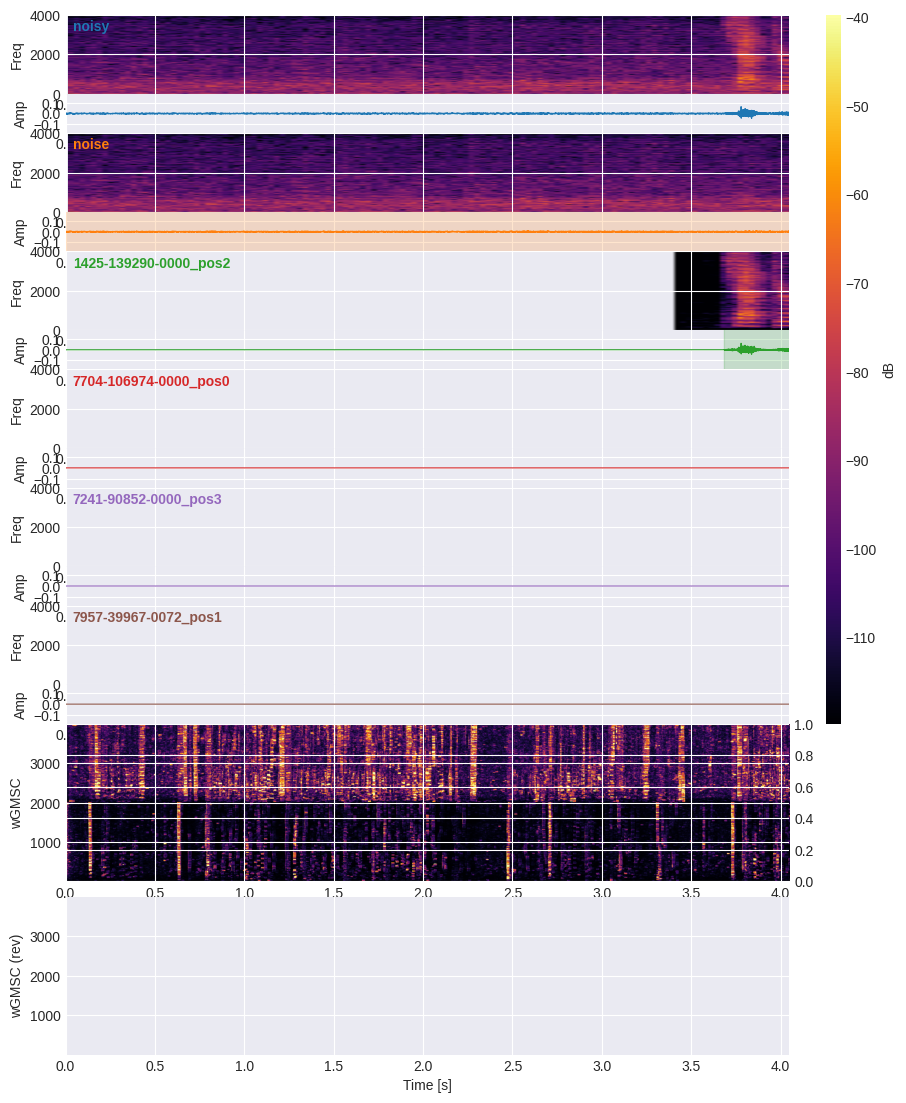

In [17]:
def create_left_plot(processed_data):
    if not processed_data: return
    labels = processed_data['labels']
    sigs = processed_data['signals']
    vads = processed_data['vads']
    time_wave = processed_data['time_wave']
    feats = processed_data['features']
    feat_time = processed_data['time_feat']
    pred = processed_data['prediction']        
    
    num_src = len(labels)
    total_rows = num_src * 2 + 3 
    
    all_sigs_vals = [sigs[lbl] for lbl in labels if lbl in sigs]
    max_amp = max([np.max(np.abs(s)) for s in all_sigs_vals if len(s) > 0], default=1.0)
    if max_amp == 0: max_amp = 1.0
    wave_ylim = [-max_amp * 1.1, max_amp * 1.1]
    
    height_ratios = []
    for _ in range(num_src):
        height_ratios.extend([2, 1])
    height_ratios.extend([4, 0.4, 4])
    
    fig_h = num_src * 1.5 + 4.5
    
    fig = plt.figure(figsize=(10, fig_h))
    gs = fig.add_gridspec(total_rows, 2, width_ratios=[50, 1], height_ratios=height_ratios, hspace=0.0, wspace=0.1)
    
    axes = []
    for r in range(total_rows):
        sharex = axes[0] if r > 0 else None
        ax = fig.add_subplot(gs[r, 0], sharex=sharex)
        axes.append(ax)
        
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    label_colors = {lbl: colors[i % 10] for i, lbl in enumerate(labels)}
    
    spec_ims = []
    global_spec_max_db = -np.inf
    
    for i, lbl in enumerate(labels):
        ax_spec = axes[i*2]
        ax_wave = axes[i*2 + 1]
        
        if lbl not in sigs: continue
        s = sigs[lbl]
        v = vads.get(lbl, None)
        c = label_colors[lbl]
        disp_lbl = lbl if not lbl.startswith("source") else f"S{lbl.split()[-1]}"
        
        Pxx, freqs, bins, im = ax_spec.specgram(s, NFFT=512, Fs=processed_data['fs'], noverlap=256, cmap='inferno')
        spec_ims.append(im)
        
        if len(Pxx) > 0:
             pxx_safe = np.maximum(Pxx, 1e-10)
             curr_max = 10 * np.log10(np.max(pxx_safe))
             if curr_max > global_spec_max_db: global_spec_max_db = curr_max
                 
        ax_spec.set_ylabel("Freq")
        ax_spec.text(0.01, 0.8, f"{disp_lbl}", transform=ax_spec.transAxes, color=c, fontweight='bold')
        
        ax_wave.plot(time_wave, s, color=c, lw=0.8)
        if v is not None:
            if len(v) != len(time_wave):
                  v_t = torch.tensor(v).float().view(1,1,-1)
                  v_up = F.interpolate(v_t, size=len(time_wave), mode='nearest')
                  v = v_up.squeeze().numpy()
            ax_wave.fill_between(time_wave, -1e9, 1e9, where=(v > 0.5), color=c, alpha=0.2, transform=ax_wave.get_xaxis_transform())
        ax_wave.set_ylabel("Amp")
        ax_wave.set_ylim(wave_ylim)
        
    if global_spec_max_db == -np.inf: global_spec_max_db = 0
    spec_vmax = global_spec_max_db
    spec_vmin = spec_vmax - 80 
    for im in spec_ims: im.set_clim(spec_vmin, spec_vmax)
        
    if spec_ims:
        cax_spec = fig.add_subplot(gs[0 : num_src*2, 1])
        fig.colorbar(spec_ims[0], cax=cax_spec, label='dB')
        
    idx_f1 = num_src * 2
    idx_spacer = idx_f1 + 1
    idx_f2 = idx_f1 + 2
    
    ax_f1 = axes[idx_f1]
    ax_spacer = axes[idx_spacer]
    ax_f2 = axes[idx_f2]
    ax_spacer.set_visible(False)
    
    fs_val = processed_data['fs']
    f_min = fs_val / 1024
    f_max = 511 * fs_val / 1024
    
    extent = [feat_time[0], feat_time[-1], f_min, f_max] if feat_time is not None else None
    feat_im = None
    
    # feats = None
    if feats is not None and extent is not None:
        feats_np = feats.float().cpu().numpy()[0]
        vmin, vmax = np.percentile(feats_np, 1), np.percentile(feats_np, 99)
        feat_im = ax_f1.imshow(feats_np[:255, :], aspect='auto', origin='lower', extent=extent, cmap='inferno', vmin=vmin, vmax=vmax)
        ax_f1.set_ylabel("wGMSC")
        ax_f2.imshow(feats_np[255:, :], aspect='auto', origin='lower', extent=extent, cmap='inferno', vmin=vmin, vmax=vmax)
        ax_f2.set_ylabel("wGMSC (rev)")
        ax_f2.set_xlabel("Time [s]")
        
        num_frames = feats.shape[1]
        # gt_count = np.zeros(num_frames)
        # for lbl in labels:
        #     if lbl in ['noisy', 'noise']: continue
        #     v = vads.get(lbl)
        #     if v is not None:
        #         v_t = torch.tensor(v).float().view(1,1,-1)
        #         v_res = F.interpolate(v_t, size=num_frames, mode='nearest')
        #         gt_count += v_res.squeeze().numpy()
        gt_count = processed_data['gt_count_frames'].float().cpu().numpy() if 'gt_count_frames' in processed_data else np.zeros(num_frames)
        
        p_np = pred.float().cpu().numpy() if pred is not None else None
        mx_c = max(np.max(gt_count), np.max(p_np) if p_np is not None else 0, 3)
        
        def add_overlay(target_ax):
            ax_t = target_ax.twinx()
            ax_t.plot(feat_time, gt_count, color='cyan', linestyle='-', lw=2, label='GT')
            if p_np is not None: ax_t.plot(feat_time, p_np, 'w--', lw=2, label='Pred')
            ax_t.set_ylabel("Count")
            ax_t.grid(False, axis='y'); ax_t.grid(False, axis='x')
            ax_t.legend(loc='upper right', frameon=True, facecolor='black', framealpha=0.6, labelcolor='white')
            ax_t.set_ylim(-0.5, mx_c + 0.5)
            
        add_overlay(ax_f1)
        add_overlay(ax_f2)
        
        if feat_im:
            cax_feat = fig.add_subplot(gs[idx_f1 : idx_f2 + 1, 1])
            fig.colorbar(feat_im, cax=cax_feat)
            
    for i, ax in enumerate(axes):
        if i == idx_spacer: continue
        ax.yaxis.grid(False)
        ax.xaxis.grid(True)
        if i != idx_f2:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            ax.set_xlabel("")
            
    axes[0].set_xlim(time_wave[0], time_wave[-1])
    plt.show()

def create_right_panel(processed_data):
    if not processed_data: return
    params = processed_data['params']
    room_dims = params.get('room_dims', [0,0,0])
    
    # Safely get mic positions
    mics = params.get('mic_pos', np.array([]))
    if isinstance(mics, list): mics = np.array(mics)
    if not isinstance(mics, np.ndarray) or mics.size == 0:
        m_arr = params.get('mic_array', np.array([]))
        if isinstance(m_arr, np.ndarray) or isinstance(m_arr, list): mics = np.array(m_arr)
        elif 'R' in params: mics = np.array(params['R'])
        else: mics = np.array([])
            
    if isinstance(mics, np.ndarray) and mics.ndim == 2:
        if mics.shape[0] == 3 and mics.shape[1] != 3: mics = mics.T 
    
    srcs = params.get('source_positions', np.array([]))
    if isinstance(srcs, list): srcs = np.array(srcs)
    if isinstance(srcs, np.ndarray) and srcs.ndim == 2:
        if srcs.shape[0] == 3 and srcs.shape[1] != 3: srcs = srcs.T
        
    center = np.mean(mics, axis=0) if len(mics) > 0 else np.array([0,0,0])
    if isinstance(center, list): center = np.array(center)
    
    L, W, H = room_dims
    
    out_audio = widgets.Output(layout={'width': '40%'})
    out_table = widgets.Output(layout={'width': '60%'})
    
    with out_audio:
        def show_audio(label, sig):
            display(HTML(f"<div style='margin-bottom: 1px; margin-top: 5px; font-weight: bold; font-size: 10pt;'>{label}</div>"))
            display(Audio(sig, rate=processed_data['fs']))
            
        for k in processed_data['labels']:
            if k in processed_data['signals']:
                show_audio(f"🔊 {k}", processed_data['signals'][k])
                
    with out_table:
        table_data = []
        include_keys = ['scenario_id', 'generator_id', 'mic_array', 'num_sources', 'signal_length', 'snr', 'rt60', 'room_dims']
        for key in include_keys:
            if key in params:
                value = params[key]
                if isinstance(value, float): display_value = f"{value:.2f}"
                elif isinstance(value, list) and len(value) > 0 and isinstance(value[0], float): display_value = f"[{', '.join([f'{v:.2f}' for v in value])}]"
                else: display_value = value
                display_key = 'Mic Array Geometry' if key == 'mic_array' else key
                table_data.append({"Parameter": display_key, "Value": display_value})
                
        radius = np.max(np.linalg.norm(mics - center, axis=1)) if len(mics) > 0 else 0
        table_data.append({"Parameter": "Mic Array Position (Center)", "Value": f"[{', '.join([f'{c:.2f}' for c in center])}]"})
        table_data.append({"Parameter": "Mic Array Radius (Approx)", "Value": f"{radius:.3f}"})
        
        if len(srcs) > 0:
            formatted_srcs = []
            for i, pos in enumerate(srcs):
                pos_str = f"[{', '.join([f'{p:.2f}' for p in pos])}]"
                doa_str = ""
                if len(center) == 3 and len(pos) == 3:
                    vec = np.array(pos) - np.array(center)
                    az = np.degrees(np.arctan2(vec[1], vec[0]))
                    xy_dist = np.linalg.norm(vec[:2])
                    el = np.degrees(np.arctan2(vec[2], xy_dist))
                    doa_str = f" (Az: {az:.1f}°, El: {el:.1f}°)"
                formatted_srcs.append(f"<b>Src {i+1}:</b> {pos_str}{doa_str}")
            table_data.append({"Parameter": "Source Positions", "Value": "<br>".join(formatted_srcs)})
            
        df = pd.DataFrame(table_data)
        display(HTML(df.to_html(index=False, escape=False, classes='table table-striped')))
        
    display(widgets.HBox([out_audio, out_table]))
    
    out_3d = widgets.Output(layout={'width': '100%'})
    with out_3d:
        x_l, y_l, z_l = [], [], []
        x_l += [0, L, L, 0, 0]; y_l += [0, 0, W, W, 0]; z_l += [0, 0, 0, 0, 0]
        x_l.append(None); y_l.append(None); z_l.append(None)
        x_l += [0, L, L, 0, 0]; y_l += [0, 0, W, W, 0]; z_l += [H, H, H, H, H]
        x_l.append(None); y_l.append(None); z_l.append(None)
        for x, y in [(0,0), (L,0), (L,W), (0,W)]:
            x_l += [x, x, None]; y_l += [y, y, None]; z_l += [0, H, None]
            
        fig3d = go.Figure()
        fig3d.add_trace(go.Scatter3d(x=x_l, y=y_l, z=z_l, mode='lines', line=dict(color='black', width=3), name='Room', hoverinfo='skip'))
        
        if len(mics) > 0:
            fig3d.add_trace(go.Scatter3d(x=mics[:,0], y=mics[:,1], z=mics[:,2], mode='markers', marker=dict(size=4, color='blue'), name='Mics'))
        fig3d.add_trace(go.Scatter3d(x=[center[0]], y=[center[1]], z=[center[2]], mode='markers', marker=dict(size=4, color='red'), name='Center'))
        
        if len(srcs) > 0:
            fig3d.add_trace(go.Scatter3d(x=srcs[:,0], y=srcs[:,1], z=srcs[:,2], mode='markers+text', marker=dict(size=6, color='green', symbol='diamond'), text=[f"S{i+1}" for i in range(len(srcs))], name='Srcs'))
            
        left_h_inches = len(processed_data['labels']) * 1.5 + 4.5
        target_h = max(int(left_h_inches * 90 - 350), 500)
        
        fig3d.update_layout(
            scene=dict(xaxis=dict(range=[0, L], title='X'), yaxis=dict(range=[0, W], title='Y'), zaxis=dict(range=[0, H], title='Z'), aspectmode='data'),
            margin=dict(l=20, r=20, b=20, t=60), height=target_h, title=dict(text="Interactive 3D View", y=0.95), legend=dict(yanchor="top", y=0.9, xanchor="right", x=0.9)
        )
        display(go.FigureWidget(fig3d))
    display(out_3d)

w_scenario_id = widgets.IntText(value=0, description='Scenario ID:')
w_btn_load = widgets.Button(description="Load Scenario", button_style='primary')
w_out_left = widgets.Output(layout={'width': '50%', 'border': '1px solid #ccc'})
w_out_right = widgets.Output(layout={'width': '50%', 'border': '1px solid #ccc', 'padding': '10px'})
w_status = widgets.Label(value="Ready.")

main_view = widgets.HBox([w_out_left, w_out_right])

def on_load_click(b):
    w_status.value = "Loading..."
    scen_id = w_scenario_id.value
    
    try:
        if scen_id >= len(dataset):
            w_status.value = f"Error: Scenario ID {scen_id} out of range (max {len(dataset)-1})"
            return
        
        item = dataset[scen_id]
        item_raw = dataset_raw[scen_id]

        proc_data = preprocess_item(item, item_raw)

        with w_out_left:
            clear_output(wait=True)
            create_left_plot(proc_data)
            
        with w_out_right:
            clear_output(wait=True)
            create_right_panel(proc_data)
            
        w_status.value = f"Loaded Scenario {scen_id} successfully."
    except Exception as e:
        w_status.value = f"Error: {str(e)}"
        import traceback
        # i can not see the following print statemnt! Why is that and how can amke it visible ?
        traceback.print_exc()

w_btn_load.on_click(on_load_click)

header = widgets.HBox([w_scenario_id, w_btn_load, w_status])
dashboard = widgets.VBox([header, main_view])

# display(dashboard)

scen_id = 0
item = dataset[scen_id]
item_raw = dataset_raw[scen_id]

proc_data = preprocess_item(item, item_raw)

with w_out_left:
    clear_output(wait=True)
    create_left_plot(proc_data)

with w_out_right:
    clear_output(wait=True)
    create_right_panel(proc_data)

In [18]:
item = dataset[2]
print(item['meta']['scenario_id'])

J3_sanity_check_train_generator_2
